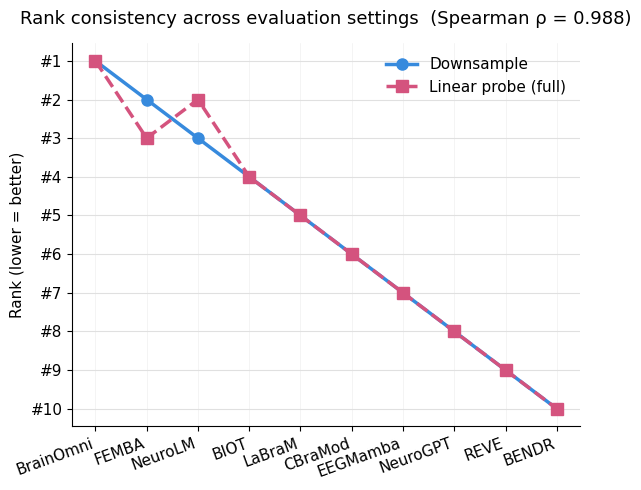

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models = ['BrainOmni', 'FEMBA', 'NeuroLM', 'BIOT', 'LaBraM',
          'CBraMod', 'EEGMamba', 'NeuroGPT', 'REVE', 'BENDR']
downsample = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
full       = [1, 3, 2, 4, 5, 6, 7, 8, 9, 10]

def spearman_rho(a, b):
    n = len(a)
    d2 = sum((x - y) ** 2 for x, y in zip(a, b))
    return 1 - 6 * d2 / (n * (n ** 2 - 1))

rho = spearman_rho(downsample, full)
x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(x, downsample, color='#378ADD', linewidth=2.5,
        marker='o', markersize=8, label='Downsample')
ax.plot(x, full, color='#D4537E', linewidth=2.5, linestyle='--',
        marker='s', markersize=8, label='Linear probe (full)')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=11)
ax.set_yticks(range(1, 11))
ax.set_yticklabels([f'#{i}' for i in range(1, 11)], fontsize=11)
ax.invert_yaxis()
ax.set_ylabel('Rank (lower = better)', fontsize=11)
ax.set_title(f'Rank consistency across evaluation settings  (Spearman ρ = {rho:.3f})',
             fontsize=13, fontweight='normal', pad=14)

ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
ax.grid(axis='x', color='#f0f0f0', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=11, framealpha=0)

plt.tight_layout()
plt.savefig('rank_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('rank_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

cross

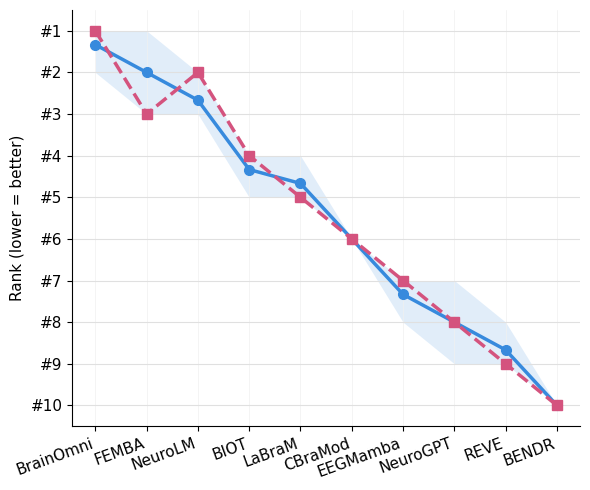

In [8]:
import matplotlib.pyplot as plt
import numpy as np

models = ['BrainOmni', 'FEMBA', 'NeuroLM', 'BIOT', 'LaBraM',
          'CBraMod', 'EEGMamba', 'NeuroGPT', 'REVE', 'BENDR']

ds1  = [2, 1, 3, 4, 5, 6, 8, 7, 9, 10]
ds2  = [1, 3, 2, 5, 4, 6, 7, 9, 8, 10]
ds3  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
full = [1, 3, 2, 4, 5, 6, 7, 8, 9, 10]

data = np.array([ds1, ds2, ds3])
mean = data.mean(axis=0)
lo   = data.min(axis=0)
hi   = data.max(axis=0)

def spearman_rho(a, b):
    n = len(a)
    d2 = sum((x - y) ** 2 for x, y in zip(a, b))
    return 1 - 6 * d2 / (n * (n ** 2 - 1))

rho = spearman_rho(mean.round().astype(int).tolist(), full)

x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(6, 5))

# shade band (min–max)
ax.fill_between(x, lo, hi, color='#378ADD', alpha=0.15, linewidth=0, label='Downsample range (min–max)')

# mean line
ax.plot(x, mean, color='#378ADD', linewidth=2.5, marker='o', markersize=7, label='Downsample mean')

# full line
ax.plot(x, full, color='#D4537E', linewidth=2.5, linestyle='--', marker='s', markersize=7, label='Linear probe (full)')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=11)
ax.set_yticks(range(1, 11))
ax.set_yticklabels([f'#{i}' for i in range(1, 11)], fontsize=11)
ax.invert_yaxis()
ax.set_ylim(10.5, 0.5)
ax.set_ylabel('Rank (lower = better)', fontsize=11)
# ax.set_title(
#     f'Rank consistency: downsample vs. linear full  (Spearman ρ = {rho:.3f})',
#     fontsize=13, fontweight='normal', pad=14
# )

ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
ax.grid(axis='x', color='#f0f0f0', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
# ax.legend(fontsize=11, framealpha=0, loc='lower right')

plt.tight_layout()
plt.savefig('rank_mean_shade.pdf', dpi=300, bbox_inches='tight')
plt.savefig('rank_mean_shade.png', dpi=300, bbox_inches='tight')
plt.show()

within

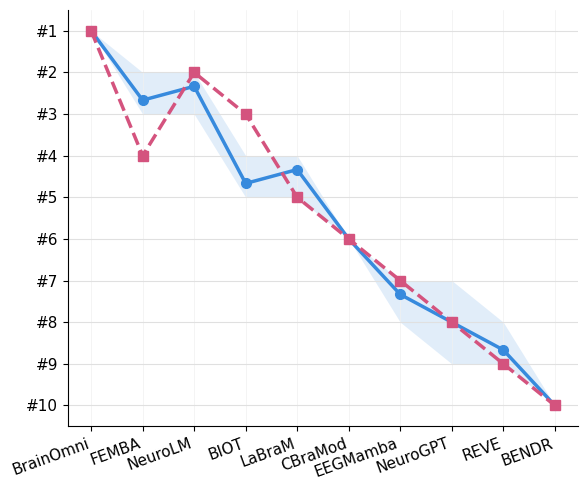

In [11]:
import matplotlib.pyplot as plt
import numpy as np

models = ['BrainOmni', 'FEMBA', 'NeuroLM', 'BIOT', 'LaBraM',
          'CBraMod', 'EEGMamba', 'NeuroGPT', 'REVE', 'BENDR']

ds1  = [1, 2, 3, 5, 4, 6, 8, 7, 9, 10]
ds2  = [1, 3, 2, 5, 4, 6, 7, 9, 8, 10]
ds3  = [1, 3, 2, 4, 5, 6, 7, 8, 9, 10]
full = [1, 4, 2, 3, 5, 6, 7, 8, 9, 10]

data = np.array([ds1, ds2, ds3])
mean = data.mean(axis=0)
lo   = data.min(axis=0)
hi   = data.max(axis=0)

def spearman_rho(a, b):
    n = len(a)
    d2 = sum((x - y) ** 2 for x, y in zip(a, b))
    return 1 - 6 * d2 / (n * (n ** 2 - 1))

rho = spearman_rho(mean.round().astype(int).tolist(), full)

x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(6, 5))

# shade band (min–max)
ax.fill_between(x, lo, hi, color='#378ADD', alpha=0.15, linewidth=0, label='Downsample range (min–max)')

# mean line
ax.plot(x, mean, color='#378ADD', linewidth=2.5, marker='o', markersize=7, label='Downsample mean')

# full line
ax.plot(x, full, color='#D4537E', linewidth=2.5, linestyle='--', marker='s', markersize=7, label='Linear probe (full)')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=11)
ax.set_yticks(range(1, 11))
ax.set_yticklabels([f'#{i}' for i in range(1, 11)], fontsize=11)
ax.invert_yaxis()
ax.set_ylim(10.5, 0.5)
# ax.set_ylabel('Rank (lower = better)', fontsize=11)
# ax.set_title(
#     f'Rank consistency: downsample (mean of 3 runs) vs. linear full  (Spearman ρ = {rho:.3f})',
#     fontsize=13, fontweight='normal', pad=14
# )

ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
ax.grid(axis='x', color='#f0f0f0', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
# ax.legend(fontsize=11, framealpha=0, loc='lower right')

plt.tight_layout()
plt.savefig('rank_mean_shade.pdf', dpi=300, bbox_inches='tight')
plt.savefig('rank_mean_shade.png', dpi=300, bbox_inches='tight')
plt.show()

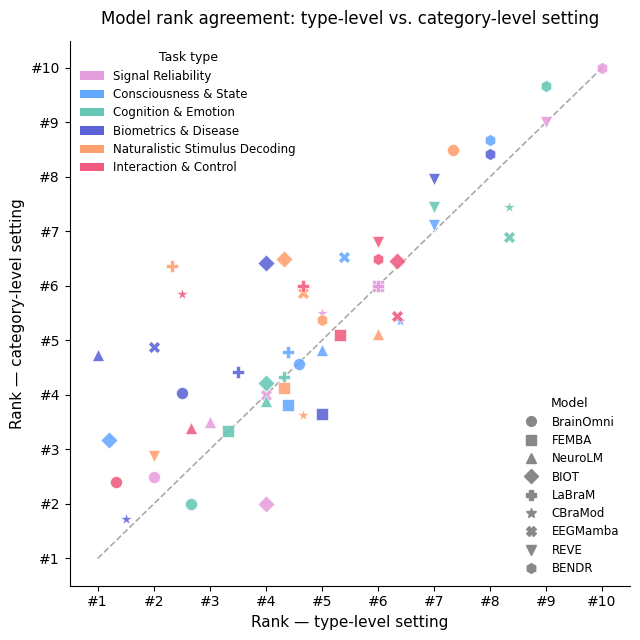

In [25]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# ── data ──────────────────────────────────────────────────────────────────────
shared_models = ['BrainOmni', 'FEMBA', 'NeuroLM', 'BIOT', 'LaBraM', 'CBraMod', 'EEGMamba', 'REVE', 'BENDR']

type_data = {
    'Signal Reliability':             {'BrainOmni':2.0,   'FEMBA':6.0,   'NeuroLM':3.0,  'BIOT':4.0,  'LaBraM':6.0,  'CBraMod':5.0,  'EEGMamba':4.0,  'REVE':9.0, 'BENDR':10.0},
    'Consciousness & State':          {'BrainOmni':4.6,   'FEMBA':4.4,   'NeuroLM':5.0,  'BIOT':1.2,  'LaBraM':4.4,  'CBraMod':6.4,  'EEGMamba':5.4,  'REVE':7.0, 'BENDR':8.0},
    'Cognition & Emotion':            {'BrainOmni':2.667, 'FEMBA':3.333, 'NeuroLM':4.0,  'BIOT':4.0,  'LaBraM':4.333,'CBraMod':8.333,'EEGMamba':8.333,'REVE':7.0, 'BENDR':9.0},
    'Biometrics & Disease':           {'BrainOmni':2.5,   'FEMBA':5.0,   'NeuroLM':1.0,  'BIOT':4.0,  'LaBraM':3.5,  'CBraMod':1.5,  'EEGMamba':2.0,  'REVE':7.0, 'BENDR':8.0},
    'Naturalistic Stimulus Decoding': {'BrainOmni':7.333, 'FEMBA':4.333, 'NeuroLM':6.0,  'BIOT':4.333,'LaBraM':2.333,'CBraMod':4.667,'EEGMamba':4.667,'REVE':2.0, 'BENDR':5.0},
    'Interaction & Control':          {'BrainOmni':1.333, 'FEMBA':5.333, 'NeuroLM':2.667,'BIOT':6.333,'LaBraM':4.667,'CBraMod':2.5,  'EEGMamba':6.333,'REVE':6.0, 'BENDR':6.0},
}
cat_data = {
    'Signal Reliability':             {'BrainOmni':2.5,   'FEMBA':6.0,   'NeuroLM':3.5,  'BIOT':2.0,  'LaBraM':6.0,  'CBraMod':5.5,  'EEGMamba':4.0,  'REVE':9.0,  'BENDR':10.0},
    'Consciousness & State':          {'BrainOmni':4.559, 'FEMBA':3.824, 'NeuroLM':4.824,'BIOT':3.176,'LaBraM':4.794,'CBraMod':5.353,'EEGMamba':6.529,'REVE':7.118,'BENDR':8.676},
    'Cognition & Emotion':            {'BrainOmni':2.0,   'FEMBA':3.333, 'NeuroLM':3.889,'BIOT':4.222,'LaBraM':4.333,'CBraMod':7.444,'EEGMamba':6.889,'REVE':7.444,'BENDR':9.667},
    'Biometrics & Disease':           {'BrainOmni':4.038, 'FEMBA':3.654, 'NeuroLM':4.731,'BIOT':6.423,'LaBraM':4.423,'CBraMod':1.731,'EEGMamba':4.885,'REVE':7.962,'BENDR':8.423},
    'Naturalistic Stimulus Decoding': {'BrainOmni':8.5,   'FEMBA':4.125, 'NeuroLM':5.125,'BIOT':6.5,  'LaBraM':6.375,'CBraMod':3.625,'EEGMamba':5.875,'REVE':2.875,'BENDR':5.375},
    'Interaction & Control':          {'BrainOmni':2.4,   'FEMBA':5.1,   'NeuroLM':3.4,  'BIOT':6.45, 'LaBraM':6.0,  'CBraMod':5.85, 'EEGMamba':5.45, 'REVE':6.8,  'BENDR':6.5},
}

cat_palette = {
    'Signal Reliability':             '#E59EDD',
    'Consciousness & State':          '#63A8FF',
    'Cognition & Emotion':            '#66C7B4',
    'Biometrics & Disease':           '#5B63D6',
    'Naturalistic Stimulus Decoding': '#FF9F6E',
    'Interaction & Control':          '#F05A7E',
}
model_markers = {
    'BrainOmni': 'o',
    'FEMBA':     's',
    'NeuroLM':   '^',
    'BIOT':      'D',
    'LaBraM':    'P',
    'CBraMod':   '*',
    'EEGMamba':  'X',
    'REVE':      'v',
    'BENDR':     'h',
}

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for cat, color in cat_palette.items():
    for model in shared_models:
        ax.scatter(type_data[cat][model], cat_data[cat][model],
                   c=color, marker=model_markers[model],
                   s=75, alpha=0.88,
                   edgecolors='white', linewidths=0.5,
                   zorder=3)

ax.plot([1, 10], [1, 10], color='#aaaaaa', linewidth=1.2, linestyle='--', zorder=2)

# ── 双图例 ────────────────────────────────────────────────────────────────────
type_handles = [
    mpatches.Patch(facecolor=color, edgecolor='none', label=cat)
    for cat, color in cat_palette.items()
]
model_handles = [
    mlines.Line2D([], [], color='#888888', marker=mk, linestyle='None',
                  markersize=7, label=m)
    for m, mk in model_markers.items()
]

leg1 = ax.legend(handles=type_handles, title='Task type', title_fontsize=9,
                 fontsize=8.5, framealpha=0, loc='upper left',
                 labelspacing=0.45)
ax.add_artist(leg1)
ax.legend(handles=model_handles, title='Model', title_fontsize=9,
          fontsize=8.5, framealpha=0, loc='lower right',
          labelspacing=0.45)

# ── axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.5)
ax.set_xticks(range(1, 11))
ax.set_yticks(range(1, 11))
ax.set_xticklabels([f'#{i}' for i in range(1, 11)], fontsize=10)
ax.set_yticklabels([f'#{i}' for i in range(1, 11)], fontsize=10)
ax.set_xlabel('Rank — type-level setting',     fontsize=11)
ax.set_ylabel('Rank — category-level setting', fontsize=11)
ax.set_title('Model rank agreement: type-level vs. category-level setting',
             fontsize=12, fontweight='normal', pad=12)

# ax.grid(color='#e8e8e8', linewidth=0.7, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('rank_scatter.pdf', dpi=300, bbox_inches='tight')
plt.savefig('rank_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

  from pathlib import Path
  import pandas as pd

  root = Path("/eeg-h5-files/zarr_data/wsn/PD31")

  idx = pd.read_parquet(root / "sample_index.parquet")

  print("rows", len(idx))
  print("columns", list(idx.columns))

  print("label_id_counts", idx["label_id"].value_counts().sort_index().to_dict())

  if "label_raw" in idx.columns:
      print("label_raw_counts", idx["label_raw"].value_counts().sort_index().to_dict())

  print("label_id_label_raw_pairs")
  print(idx[["label_id", "label_raw"]].value_counts().sort_index())

  print("vocab", json.loads((root / "label_vocab.json").read_text()))

  print("head")
  print(idx[["sample_id", "subject_id", "label_id", "label_raw"]].head(10).to_string(index=False))

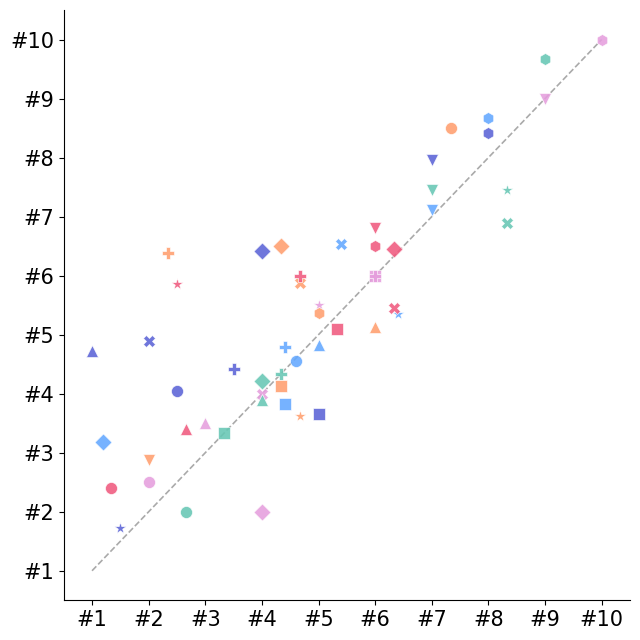

In [26]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

shared_models = ['BrainOmni', 'FEMBA', 'NeuroLM', 'BIOT', 'LaBraM', 'CBraMod', 'EEGMamba', 'REVE', 'BENDR']

# type_data = {
#     'Signal Reliability':             {'BrainOmni':2.0,   'FEMBA':3.0,   'NeuroLM':1.0,  'BIOT':5.0,  'LaBraM':6.0,  'CBraMod':7.0,  'EEGMamba':8.0,  'REVE':9.0,  'BENDR':10.0},
#     'Consciousness & State':          {'BrainOmni':4.6,   'FEMBA':4.4,   'NeuroLM':6.0,  'BIOT':1.2,  'LaBraM':4.4,  'CBraMod':6.4,  'EEGMamba':5.4,  'REVE':7.0,  'BENDR':8.0},
#     'Cognition & Emotion':            {'BrainOmni':2.667, 'FEMBA':3.333, 'NeuroLM':4.0,  'BIOT':4.0,  'LaBraM':4.333,'CBraMod':8.333,'EEGMamba':8.333,'REVE':7.0,  'BENDR':9.0},
#     'Biometrics & Disease':           {'BrainOmni':2.5,   'FEMBA':5.0,   'NeuroLM':1.0,  'BIOT':4.0,  'LaBraM':3.5,  'CBraMod':1.5,  'EEGMamba':2.0,  'REVE':7.0,  'BENDR':8.0},
#     'Naturalistic Stimulus Decoding': {'BrainOmni':2.333, 'FEMBA':1.333, 'NeuroLM':6.0,  'BIOT':4.333,'LaBraM':2.333,'CBraMod':4.667,'EEGMamba':4.667,'REVE':2.0,  'BENDR':5.0},
#     'Interaction & Control':          {'BrainOmni':4.333, 'FEMBA':5.333, 'NeuroLM':2.667,'BIOT':6.333,'LaBraM':4.667,'CBraMod':2.5,  'EEGMamba':6.333,'REVE':6.0,  'BENDR':6.0},
# }
# cat_data = {
#     'Signal Reliability':             {'BrainOmni':2.5,   'FEMBA':6.0,   'NeuroLM':3.5,  'BIOT':2.0,  'LaBraM':6.0,  'CBraMod':5.5,  'EEGMamba':4.0,  'REVE':9.0,  'BENDR':10.0},
#     'Consciousness & State':          {'BrainOmni':4.559, 'FEMBA':3.824, 'NeuroLM':4.824,'BIOT':3.176,'LaBraM':4.794,'CBraMod':5.353,'EEGMamba':6.529,'REVE':7.118,'BENDR':8.676},
#     'Cognition & Emotion':            {'BrainOmni':2.0,   'FEMBA':3.333, 'NeuroLM':3.889,'BIOT':4.222,'LaBraM':4.333,'CBraMod':7.444,'EEGMamba':6.889,'REVE':7.444,'BENDR':9.667},
#     'Biometrics & Disease':           {'BrainOmni':4.038, 'FEMBA':3.654, 'NeuroLM':4.731,'BIOT':6.423,'LaBraM':4.423,'CBraMod':4.731,'EEGMamba':4.885,'REVE':7.962,'BENDR':8.423},
#     'Naturalistic Stimulus Decoding': {'BrainOmni':8.5,   'FEMBA':4.125, 'NeuroLM':5.125,'BIOT':6.5,  'LaBraM':6.375,'CBraMod':3.625,'EEGMamba':5.875,'REVE':2.875,'BENDR':5.375},
#     'Interaction & Control':          {'BrainOmni':2.4,   'FEMBA':5.1,   'NeuroLM':3.4,  'BIOT':6.45, 'LaBraM':6.0,  'CBraMod':5.85, 'EEGMamba':5.45, 'REVE':6.8,  'BENDR':6.5},
# }

cat_palette = {
    'Signal Reliability':             '#E59EDD',
    'Consciousness & State':          '#63A8FF',
    'Cognition & Emotion':            '#66C7B4',
    'Biometrics & Disease':           '#5B63D6',
    'Naturalistic Stimulus Decoding': '#FF9F6E',
    'Interaction & Control':          '#F05A7E',
}
model_markers = {
    'BrainOmni': 'o',
    'FEMBA':     's',
    'NeuroLM':   '^',
    'BIOT':      'D',
    'LaBraM':    'P',
    'CBraMod':   '*',
    'EEGMamba':  'X',
    'REVE':      'v',
    'BENDR':     'h',
}

fig, ax = plt.subplots(figsize=(6.5, 6.5))

for cat, color in cat_palette.items():
    for model in shared_models:
        ax.scatter(type_data[cat][model], cat_data[cat][model],
                   c=color, marker=model_markers[model],
                   s=75, alpha=0.88,
                   edgecolors='white', linewidths=0.5,
                   zorder=3)

ax.plot([1, 10], [1, 10], color='#aaaaaa', linewidth=1.2, linestyle='--', zorder=2)

ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.5)
ax.set_xticks(range(1, 11))
ax.set_yticks(range(1, 11))
ax.set_xticklabels([f'#{i}' for i in range(1, 11)], fontsize=15)
ax.set_yticklabels([f'#{i}' for i in range(1, 11)], fontsize=15)
# ax.set_xlabel('Rank — type-level setting', fontsize=11)
# ax.set_ylabel('Rank — category-level setting', fontsize=11)
# ax.set_title('Model rank agreement: type-level vs. category-level setting',
#              fontsize=12, fontweight='normal', pad=12)

# ax.grid(color='#e8e8e8', linewidth=0.7, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('rank_scatter.pdf', dpi=300, bbox_inches='tight')
plt.savefig('rank_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

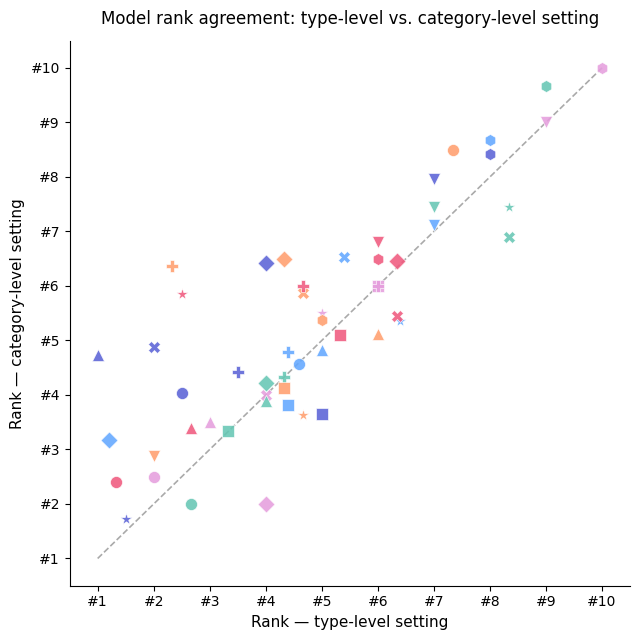

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for cat, color in cat_palette.items():
    for model in shared_models:
        ax.scatter(type_data[cat][model], cat_data[cat][model],
                   c=color, marker=model_markers[model],
                   s=75, alpha=0.88,
                   edgecolors='white', linewidths=0.5,
                   zorder=3)

ax.plot([1, 10], [1, 10], color='#aaaaaa', linewidth=1.2, linestyle='--', zorder=2)

ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.5)
ax.set_xticks(range(1, 11))
ax.set_yticks(range(1, 11))
ax.set_xticklabels([f'#{i}' for i in range(1, 11)], fontsize=10)
ax.set_yticklabels([f'#{i}' for i in range(1, 11)], fontsize=10)
ax.set_xlabel('Rank — type-level setting', fontsize=11)
ax.set_ylabel('Rank — category-level setting', fontsize=11)
ax.set_title('Model rank agreement: type-level vs. category-level setting',
             fontsize=12, fontweight='normal', pad=12)

# ax.grid(color='#e8e8e8', linewidth=0.7, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('rank_scatter.pdf', dpi=300, bbox_inches='tight')
plt.savefig('rank_scatter.png', dpi=300, bbox_inches='tight')
plt.show()